In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_test.csv
/kaggle/input/datasets/datamunge/sign-language-mnist/amer_sign2.png
/kaggle/input/datasets/datamunge/sign-language-mnist/amer_sign3.png
/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_train.csv
/kaggle/input/datasets/datamunge/sign-language-mnist/american_sign_language.PNG
/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_test/sign_mnist_test.csv
/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_train/sign_mnist_train.csv


## Section 1: Derivatives & Gradients - The Direction of Steepest Ascent
Concept: The derivative measures sensitivity to change. In AI, the Gradient ($\nabla$) points in the direction of the steepest increase of the loss function.  We want to go the opposite way.

- Intuition: Imagine standing on a foggy mountain (the Loss Surface). The gradient tells you which way is "up." To minimize loss, you step "down."
- NumPy Implementation:


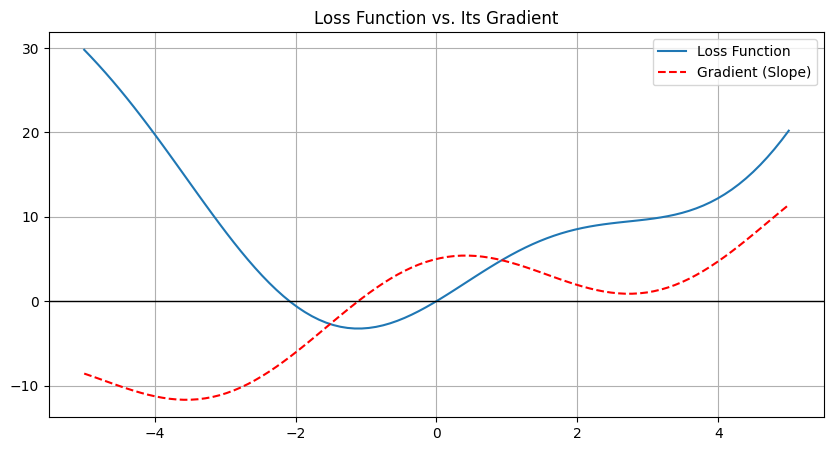

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define a simple loss function: L(w) = w^2 + 5*sin(w)
def loss(w):
    return w**2 + 5*np.sin(w)

# Define its derivative (gradient): dL/dw = 2w + 5*cos(w)
def gradient(w):
    return 2*w + 5*np.cos(w)

w = np.linspace(-5, 5, 100)
plt.figure(figsize=(10, 5))
plt.plot(w, loss(w), label='Loss Function')
plt.plot(w, gradient(w), 'r--', label='Gradient (Slope)')
plt.axhline(0, color='black', lw=1)
plt.title("Loss Function vs. Its Gradient")
plt.legend()
plt.grid(True)
plt.show()   

## Section 2: Linear Transformations - How Matrices Warp Space
Concept: Matrices transform vector spaces (rotate, scale, shear). 

- Visual Demo: Transform the unit circle/grid to see the effect.

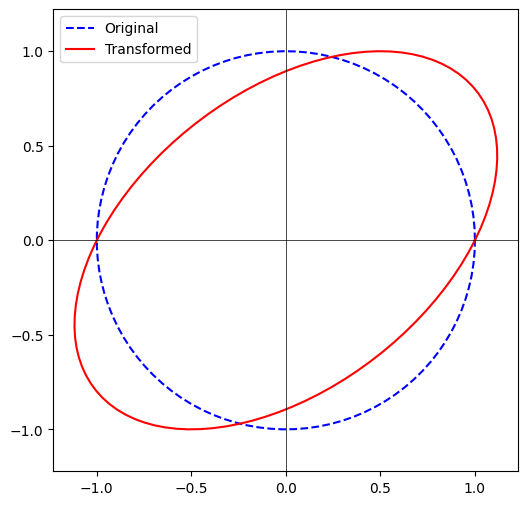

In [3]:
import matplotlib.pyplot as plt

def plot_transformation(matrix):
    # Unit circle points
    theta = np.linspace(0, 2*np.pi, 100)
    circle = np.array([np.cos(theta), np.sin(theta)])
    
    # Apply transformation
    transformed = matrix @ circle
    
    plt.figure(figsize=(6,6))
    plt.plot(circle[0], circle[1], 'b--', label='Original')
    plt.plot(transformed[0], transformed[1], 'r-', label='Transformed')
    plt.axhline(0, color='black', lw=0.5)
    plt.axvline(0, color='black', lw=0.5)
    plt.legend()
    plt.axis('equal')
    plt.show()

# Example: Shear transformation
shear = np.array([[1, 0.5], [0, 1]])
plot_transformation(shear)   

## Section 3: Eigendecomposition - Finding the "Axes" of Transformation
Concept: Eigenvectors are directions that don't rotate under transformation; eigenvalues are their scaling factors. 

- Intuition: In PCA, eigenvectors of the covariance matrix point to directions of maximum variance. 
- NumPy Implementation:

In [4]:
# Only works on square matrices
A = np.array([[3, 1], [1, 3]])
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues:", eigenvalues)      # [4. 2.]
print("Eigenvectors:\n", eigenvectors) # Directions unchanged by A   

Eigenvalues: [4. 2.]
Eigenvectors:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


## Section 4: Singular Value Decomposition (SVD) - The Universal Factorization
Concept: Any matrix (even non-square) can be decomposed into rotation → scaling → rotation. 

- Formula: $A = U \Sigma V^T$
 - $U$: Left singular vectors (output space rotation)
 - $\Sigma$: Singular values (scaling factors)
- $V^T$: Right singular vectors (input space rotation)
- NumPy Implementation:

In [5]:
# Works on ANY matrix (square or not)
B = np.array([[7, 2], [3, 4], [5, 3]])  # 3x2 matrix
U, S, Vt = np.linalg.svd(B)

print("U shape:", U.shape)    # (3, 3)
print("Singular values:", S)  # Scaling factors
print("Vt shape:", Vt.shape)  # (2, 2)

# Reconstruct original matrix
Sigma = np.zeros(B.shape)
np.fill_diagonal(Sigma, S)
B_reconstructed = U @ Sigma @ Vt
print("Reconstruction error:", np.linalg.norm(B - B_reconstructed))  # ~0   

U shape: (3, 3)
Singular values: [10.25142677  2.62835484]
Vt shape: (2, 2)
Reconstruction error: 3.4111139459141383e-15


## Section 5: Hands-On Project - Image Compression with SVD
Task: Compress a grayscale image by keeping only top-$k$ singular values.

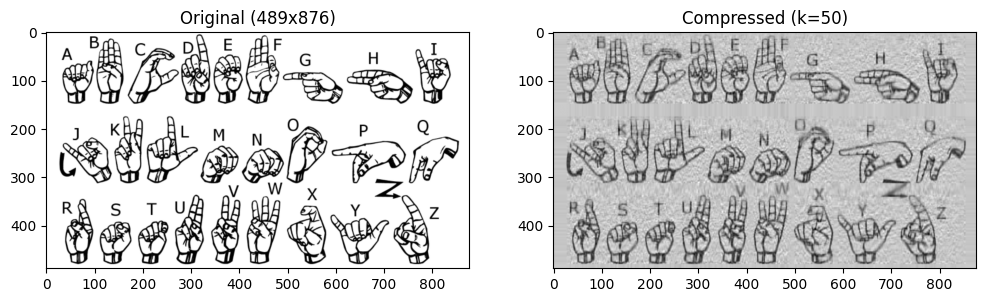

In [6]:
from PIL import Image

# Load image as matrix
img = Image.open('/kaggle/input/datasets/datamunge/sign-language-mnist/american_sign_language.PNG').convert('L')
img_matrix = np.array(img)

# Apply SVD
U, S, Vt = np.linalg.svd(img_matrix, full_matrices=False)

# Compress: keep only top 50 singular values
k = 50
compressed = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

# Display original vs compressed
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_matrix, cmap='gray')
plt.title(f'Original ({img_matrix.shape[0]}x{img_matrix.shape[1]})')
plt.subplot(1, 2, 2)
plt.imshow(compressed, cmap='gray')
plt.title(f'Compressed (k={k})')
plt.show()   

## Kaggle-Specific Tips
1. Enable GPU: SVD on large matrices benefits from GPU acceleration (Kaggle provides free GPUs).
2. Add Markdown Cells: Explain the intuition before each code block (e.g., "Why do eigenvectors matter in PCA?"). 
3. Interactive Widgets: Use ipywidgets to let users adjust singular values $k$ and see compression quality in real-time.
4. Dataset: Attach a sample dataset (e.g., MNIST or face images) for readers to experiment with.
